# Day 17 — Feature Scaling 📏

Compare KNN performance without scaling, with StandardScaler, and with MinMaxScaler using the Breast Cancer dataset.

## 🎯 Objectives

- Understand why feature scaling is important
- Learn Standardization and Min-Max Normalization
- Use `StandardScaler` and `MinMaxScaler`
- Compare KNN performance
- Evaluate the final model

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## 📊 Dataset

The Breast Cancer Wisconsin (Diagnostic) dataset contains 569 samples and 30 numerical features for binary classification.

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print('Dataset Shape:', X.shape)
display(X.head())

Dataset Shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 🔎 Feature Ranges Before Scaling

In [3]:
feature_ranges = pd.DataFrame({'Minimum': X.min(), 'Maximum': X.max(), 'Mean': X.mean(), 'Std': X.std()})
display(feature_ranges.head(10))

,Minimum,Maximum,Mean,Std
mean radius,6.98100,28.11000,14.127292,3.524049
mean texture,9.71000,39.28000,19.289649,4.301036
mean perimeter,43.79000,188.50000,91.969033,24.298981
mean area,143.50000,2501.00000,654.889104,351.914129
mean smoothness,0.05263,0.16340,0.096360,0.014064
mean compactness,0.01938,0.34540,0.104341,0.052813
mean concavity,0.00000,0.42680,0.088799,0.079720
mean concave points,0.00000,0.20120,0.048919,0.038803
mean symmetry,0.10600,0.30400,0.181162,0.027414
mean fractal dimension,0.04996,0.09744,0.062798,0.007060


## ✂️ Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print('Training Samples:', len(X_train))
print('Testing Samples :', len(X_test))

Training Samples: 455
Testing Samples : 114


## 🤖 KNN Without Scaling

In [5]:
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
pred_unscaled = knn_unscaled.predict(X_test)
accuracy_unscaled = accuracy_score(y_test, pred_unscaled)
print(f'Accuracy without scaling: {accuracy_unscaled:.4f}')

Accuracy without scaling: 0.9123


## 📐 Standardization — StandardScaler

StandardScaler transforms features so they generally have mean 0 and standard deviation 1. The scaler is fitted only on the training data.

In [6]:
standard_scaler = StandardScaler()
X_train_standard = standard_scaler.fit_transform(X_train)
X_test_standard = standard_scaler.transform(X_test)
print(X_train_standard[:5])

[[-1.07200079e+00 -6.58424598e-01 -1.08808010e+00 -9.39273639e-01
  -1.35939882e-01 -1.00871795e+00 -9.68358632e-01 -1.10203235e+00
   2.81062120e-01 -1.13231479e-01 -7.04860874e-01 -4.40938351e-01
  -7.43948977e-01 -6.29804931e-01  7.48061001e-04 -9.91572979e-01
  -6.93759567e-01 -9.83284458e-01 -5.91579010e-01 -4.28972052e-01
  -1.03409427e+00 -6.23497432e-01 -1.07077336e+00 -8.76534437e-01
  -1.69982346e-01 -1.03883630e+00 -1.07899452e+00 -1.35052668e+00
  -3.52658049e-01 -5.41380026e-01]
 [ 1.74874285e+00  6.65017334e-02  1.75115682e+00  1.74555856e+00
   1.27446827e+00  8.42288215e-01  1.51985232e+00  1.99466430e+00
  -2.93045055e-01 -3.20179716e-01  1.27567198e-01 -3.81382677e-01
   9.40746962e-02  3.17524379e-01  6.39656015e-01  8.73892616e-02
   7.08450758e-01  1.18215034e+00  4.26212305e-01  7.47970186e-02
   1.22834212e+00 -9.28334970e-02  1.18746742e+00  1.10438613e+00
   1.51700092e+00  2.49654896e-01  1.17859444e+00  1.54991557e+00
   1.91077868e-01 -1.73738602e-01]
 [-9.7

## 🤖 KNN with StandardScaler

In [7]:
knn_standard = KNeighborsClassifier(n_neighbors=5)
knn_standard.fit(X_train_standard, y_train)
pred_standard = knn_standard.predict(X_test_standard)
accuracy_standard = accuracy_score(y_test, pred_standard)
print(f'Accuracy with StandardScaler: {accuracy_standard:.4f}')

Accuracy with StandardScaler: 0.9561


## 📏 Min-Max Normalization

MinMaxScaler scales each feature to a fixed range, commonly 0 to 1.

In [8]:
minmax_scaler = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)
print(X_train_minmax[:5])

[[0.15802925 0.22455191 0.14871122 0.07701125 0.38727339 0.09373658
  0.02371134 0.02731113 0.41666667 0.25379107 0.03581387 0.13410537
  0.0282241  0.01188902 0.18264949 0.03751465 0.02555556 0.10409168
  0.10860021 0.05911861 0.13174603 0.25986141 0.11576947 0.06150671
  0.38939075 0.05930863 0.03501597 0.08182131 0.21998817 0.1242949 ]
 [0.62468645 0.33243152 0.62200263 0.46975165 0.61795839 0.39727624
  0.4997657  0.62574553 0.33535354 0.22262005 0.11645845 0.14161952
  0.10606418 0.0880651  0.25067138 0.18699492 0.14005051 0.36181095
  0.2339731  0.10745132 0.55952381 0.3478145  0.53435072 0.39848466
  0.64749032 0.25895742 0.42396166 0.7467354  0.289178   0.1686344 ]
 [0.17412088 0.18397024 0.16377583 0.08749735 0.3091617  0.07251089
  0.         0.         0.43838384 0.20619208 0.07944957 0.34582744
  0.06587193 0.02925609 0.23795764 0.05946766 0.         0.
  0.34851128 0.00370355 0.14325397 0.19136461 0.12739672 0.06871381
  0.24743598 0.03940973 0.         0.         0.225704

## 🤖 KNN with MinMaxScaler

In [9]:
knn_minmax = KNeighborsClassifier(n_neighbors=5)
knn_minmax.fit(X_train_minmax, y_train)
pred_minmax = knn_minmax.predict(X_test_minmax)
accuracy_minmax = accuracy_score(y_test, pred_minmax)
print(f'Accuracy with MinMaxScaler: {accuracy_minmax:.4f}')

Accuracy with MinMaxScaler: 0.9825


## 📊 Compare Scaling Methods

In [10]:
comparison = pd.DataFrame({'Method':['Without Scaling','StandardScaler','MinMaxScaler'],'Accuracy':[accuracy_unscaled,accuracy_standard,accuracy_minmax]})
display(comparison)

,Method,Accuracy
0,Without Scaling,0.912281
1,StandardScaler,0.956140
2,MinMaxScaler,0.982456


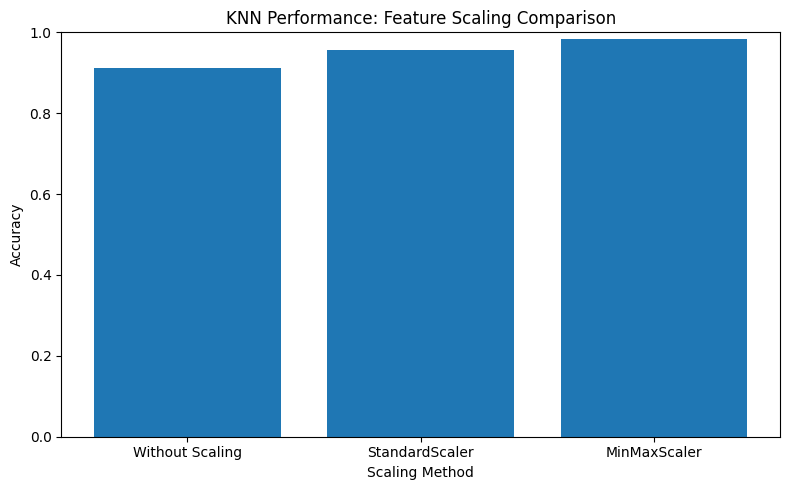

In [11]:
plt.figure(figsize=(8,5))
plt.bar(comparison['Method'], comparison['Accuracy'])
plt.ylim(0,1)
plt.ylabel('Accuracy')
plt.xlabel('Scaling Method')
plt.title('KNN Performance: Feature Scaling Comparison')
plt.tight_layout()
plt.show()

## 📦 Feature Distribution Before Scaling

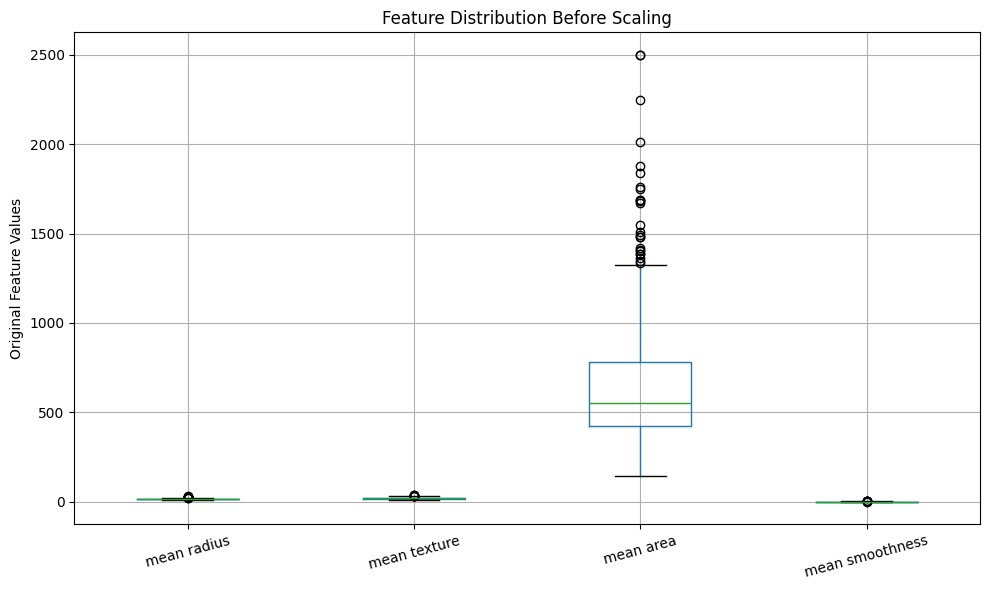

In [12]:
selected_columns = ['mean radius','mean texture','mean area','mean smoothness']
plt.figure(figsize=(10,6))
X[selected_columns].boxplot()
plt.title('Feature Distribution Before Scaling')
plt.ylabel('Original Feature Values')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 📦 Feature Distribution After Standardization

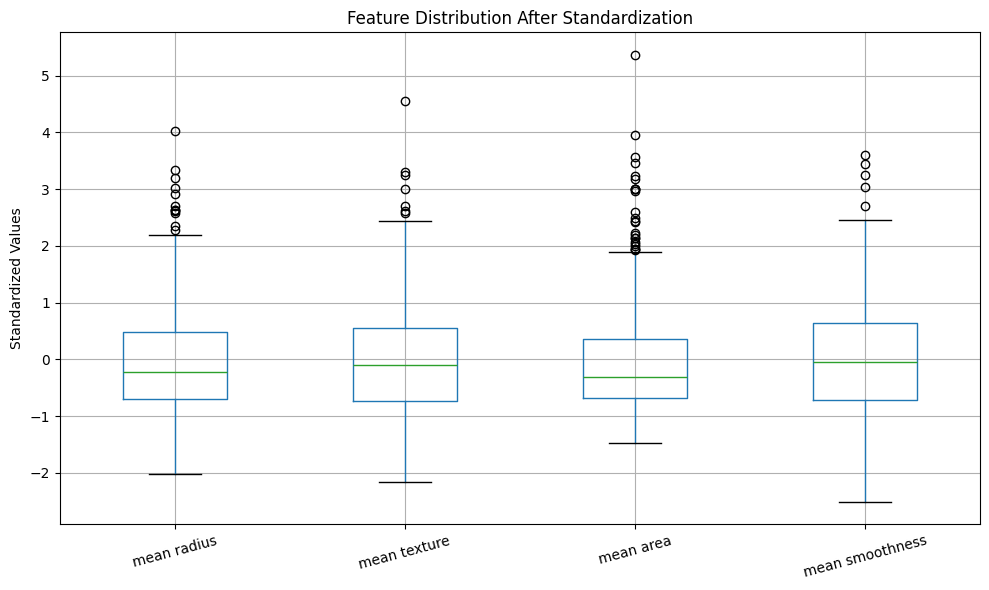

In [13]:
standard_df = pd.DataFrame(X_train_standard, columns=X_train.columns)
plt.figure(figsize=(10,6))
standard_df[selected_columns].boxplot()
plt.title('Feature Distribution After Standardization')
plt.ylabel('Standardized Values')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 🔲 Confusion Matrix — Standardized KNN

[[39  3]
 [ 2 70]]


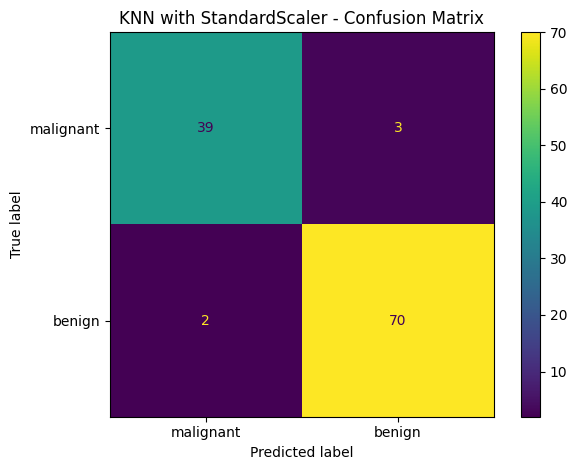

In [14]:
cm = confusion_matrix(y_test, pred_standard)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot()
plt.title('KNN with StandardScaler - Confusion Matrix')
plt.tight_layout()
plt.show()

## 📋 Classification Report

In [15]:
print(classification_report(y_test, pred_standard, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## 🔑 Key Findings

- KNN is distance-based, so feature scale can affect its predictions.
- StandardScaler standardizes numerical features.
- MinMaxScaler scales features to a fixed range.
- The three approaches are compared using test accuracy.
- Scaling should be fitted only on training data to avoid data leakage.

## 🧠 Key Learnings

Feature Scaling is an important preprocessing step for distance-based algorithms such as KNN. The practical effect of different scaling techniques can be understood by comparing model performance before and after scaling.

## 🏁 Conclusion

KNN was trained using the original data, standardized data, and Min-Max scaled data. Comparing these approaches demonstrates why choosing an appropriate feature-scaling method matters in machine learning.

## 📚 References

- Scikit-learn — StandardScaler
  https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

- Scikit-learn — MinMaxScaler
  https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html

- Scikit-learn — KNeighborsClassifier
  https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

- Scikit-learn — Breast Cancer Dataset
  https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html

## 📅 30 Days of Machine Learning

**Day 17/30 — Feature Scaling 📏**

Learning → Coding → Experimenting → Evaluating 🚀